# INTRODUCTION:

# NYC Taxi Fare Prediction - End-to-End Machine Learning Project

The goal of this project is to build an end-to-end machine learning pipeline that predicts
taxi fare amounts for trips in New York City using historical trip data.

* **Inputs:** Trip characteristics such as pickup and dropoff locations
(latitude and longitude), pickup date and time, passenger count, and trip
distance derived from geographic coordinates.
* **Outputs:** Taxi fare amount (in USD).

This is a **regression problem** since the target variable i.e **fare_amount** is a continuous or numerical value.

Additionally, because taxi fares are predicted based on historical trips
and evaluated on trips occurring later in time, this project also follows
a **time-aware forecasting approach**, where models are trained on past data and evaluated on future data.

The dataset used in this project comes from publicly available
NYC Yellow Taxi Trip data provided via Kaggle, and model performance is
evaluated using **Root Mean Squared Error (RMSE)** and
**Root Mean Squared Log Error (RMSLE)**.

# Dataset: **NYC Yellow Taxi Trip Fare Prediction**

NYC Taxi Fare Prediction – Kaggle

🔗 https://www.kaggle.com/c/new-york-city-taxi-fare-prediction/data

# Objective

The objective of this project is to build a complete end-to-end machine learning pipeline that predicts the fare_amount for NYC Yellow Taxi trips using historical trip data.

# Real-World Importance

Helps ride-hailing platforms estimate fares accurately

Assists drivers and passengers with transparency

Demonstrates applied data science skills: cleaning, feature engineering, modeling, and evaluation

## Overview

Since we already have a dataset, we'll approach the problem with the following machine learning modelling framework.

| <img src="https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/images/supervised-projects-6-step-ml-framework-tools-highlight.png?raw=true" width=750/> | 
|:--:| 
| 6 Step Machine Learning Modelling Framework ([read more](https://whimsical.com/9g65jgoRYTxMXxDosndYTB)) |

To work through these topics, we'll use pandas, Matplotlib and NumPy for data analysis, as well as, Scikit-Learn for machine learning and modelling tasks.

| <img src="https://github.com/mrdbourke/zero-to-mastery-ml/blob/master/images/supervised-projects-6-step-ml-framework-tools-highlight.png?raw=true" width=750/> | 
|:--:| 
| Tools that can be used for each step of the machine learning modelling process. |

We'll work through each step and by the end of the notebook, we'll have a trained machine learning model which predicts the sale price of a bulldozer given different characteristics about it.

# 6 Step Machine Learning Framework

# Problem Definition

New York City taxi fares depend on multiple factors such as trip distance, pickup/dropoff locations, time of day and passenger count. For this dataset, the problem we are trying to solve is:

**"How accurately can we predict the fare amount of a New York City taxi trip given trip characteristics and historical examples of similar taxi rides?"**

This involves learning patterns from past taxi trips and applying them to predict fares for future trips.


# Data

The dataset used in this project comes from the New York City Taxi Fare Prediction dataset available on Kaggle, which is based on real NYC Yellow Taxi trip records.The dataset contains historical taxi trip information, including pickup and dropoff locations, trip timestamps, passenger counts, and fare amounts.

There are three main files provided in the Kaggle dataset:

1. **train.csv** - 
Contains historical taxi trip data with fare_amount included

Used for training and validating machine learning models

This file includes the target variable (fare_amount)

2. **test.csv** - Contains taxi trip information without fare amounts


3. **sample_submission.csv** - Contains no useful feature data


> **Note:** Due to the large size of the dataset, a representative subset of the training data (train.csv) is used to ensure efficient computation.

# Evaluation

For this problem, model performance is evaluated using **Root Mean Squared Error (RMSE)** and **Root Mean Squared Log Error (RMSLE).**

**RMSE** measures the average prediction error in dollar amounts, making it easy to interpret how far the model’s predictions are from the actual taxi fares. 

**RMSLE** penalizes large relative errors and is particularly useful when predicting both low-cost and high-cost trips.

For regression problems, the goal is to minimize both error metrics since lower values indicate predictions that are closer to the true fare amounts.

To assess model performance, RMSE and RMSLE are calculated on a time-aware validation set ensuring that the model is evaluated on trips occurring later in time than those used for training.

# Key Features

Features are the different attributes and characteristics of the data that are used to make predictions.

One of the most effective ways to understand a dataset is by creating a data dictionary, which describes each variable and its role in the problem.

For this dataset, Kaggle provides a description of the NYC Taxi Fare Prediction data, which is based on real New York City Yellow Taxi trip records.

Below is a simplified data dictionary for the key features used in this project.

| Variable Name        | Description                                                  | Variable Type                |
|---------------------|--------------------------------------------------------------|------------------------------|
| key                 | Unique identifier for each taxi trip                          | Independent                  |
| pickup_datetime     | Date and time when the taxi trip started                      | Independent                  |
| pickup_longitude    | Longitude coordinate of pickup location                       | Independent                  |
| pickup_latitude     | Latitude coordinate of pickup location                        | Independent                  |
| dropoff_longitude   | Longitude coordinate of dropoff location                      | Independent                  |
| dropoff_latitude    | Latitude coordinate of dropoff location                       | Independent                  |
| passenger_count     | Number of passengers in the taxi                              | Independent                  |
| trip_distance_km    | Distance of the trip calculated using the Haversine formula   | Engineered Feature           |
| hour                | Hour of the day when the trip started                         | Engineered Feature           |
| day                 | Day of the month when the trip started                        | Engineered Feature           |
| month               | Month when the trip occurred                                  | Engineered Feature           |
| weekday             | Day of the week (0 = Monday, 6 = Sunday)                      | Engineered Feature           |
| fare_amount         | Total fare charged for the taxi trip (USD)                    | **Target / Dependent Variable** |

Note: Some features, such as trip distance and time-based components, are not directly available in the raw dataset and are derived through feature engineering to improve model performance.

With an understanding of the available features and their meanings, we can now proceed to import the dataset and begin exploring its structure and contents.

In [128]:
# Timestamp
import datetime

import datetime
print(f"Notebook last run (end-to-end): {datetime.datetime.now()}")

Notebook last run (end-to-end): 2025-12-16 21:01:07.251134


#### Importing the data and preparing it for modelling

First things first, we’ll import the libraries required for data analysis and machine learning, along with loading the dataset needed for this project.

We’ll begin by importing **pandas**, **NumPy**, and **matplotlib** which will be used throughout the notebook for data manipulation, numerical operations and data visualization.

In [178]:
# Import data analysis tools 
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Print the versions
print(f"pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"matplotlib version: {matplotlib.__version__}") 

pandas version: 2.2.3
NumPy version: 2.1.3
matplotlib version: 3.10.0


Now that our data analysis tools are ready, we can import the dataset and start exploring it.

For this project, the data is downloaded from Kaggle (New York City Taxi Fare Prediction dataset) and stored locally in the project directory under the path: data/train.csv

Due to the large size of the dataset, a representative subset of the data is loaded to ensure efficient computation and faster experimentation.

In [130]:
from pathlib import Path

# Define dataset path (absolute path on Windows)
dataset_path = Path(r"C:\Users\Sameer\train.csv")

if not dataset_path.is_file():
    print("[INFO] train.csv not found at the specified location.")
else:
    print("[INFO] NYC Taxi Fare dataset found!")
    print(f"[INFO] Dataset path: {dataset_path}")

[INFO] NYC Taxi Fare dataset found!
[INFO] Dataset path: C:\Users\Sameer\train.csv


Dataset downloaded!

Let's check what files are available.

#### Exploring the Dataset

Now that the dataset has been successfully loaded, we can begin exploring its structure
and contents. This helps us understand the available features, data types, and
identify any potential issues such as missing values or incorrect data formats.

In [131]:
from pathlib import Path
import os

dataset_path = Path(r"C:\Users\Sameer")

print(f"[INFO] Files available in {dataset_path}:")
os.listdir(dataset_path)

[INFO] Files available in C:\Users\Sameer:


['.anaconda',
 '.conda',
 '.condarc',
 '.continuum',
 '.dotnet',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.python_history',
 '.spyder-py3',
 '.templateengine',
 '.VirtualBox',
 '234',
 '3D Objects',
 '543',
 'AI lab11.ipynb',
 'AI lab9.ipynb',
 'Ali_Raza_Certificate.pdf',
 'anaconda_projects',
 'AppData',
 'Application Data',
 'Ayesha_Khan_Certificate.pdf',
 'car-sales.csv',
 'carNewData.csv',
 'cd',
 'cleaned_dataset.csv',
 'Contacts',
 'Cookies',
 'Desktop',
 'Documents',
 'Downloads',
 'extended_car_sales.csv',
 'Favorites',
 'heart-disease.csv',
 'Jedi',
 'Links',
 'Local Settings',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TM.blf',
 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{53b39e88-18c4-11ea-a811-000d3aa4692b}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'Pi

You can explore the available files individually or read more about the dataset on the Kaggle competition page.

For this project, the primary file we are interested in is train.csv, which contains historical New York City taxi trip data along with the corresponding fare amounts. This file serves as the main dataset for both training and validation.

The dataset includes taxi trip records with timestamps, pickup and dropoff locations, passenger counts and the total fare charged for each trip. Since the data spans multiple dates and times, it allows us to perform a time-aware split, where earlier trips are used for training and later trips are used for testing.

We will use the training portion of the data to fit our machine learning models and then evaluate their performance on trips that occur later in time. This approach better reflects a real-world scenario, where models are trained on past data to make predictions about future trips.

For now, let’s import the train.csv file and convert it into a pandas DataFrame so we can begin exploring and preparing the data for modelling.

In [132]:
# Import the training and validation set
df = pd.read_csv('train.csv')
df.head()

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2009-06-15 17:26:21.0000001,4.5,2009-06-15 17:26:21 UTC,-73.844311,40.721319,-73.841610,40.712278,1.0
1,2010-01-05 16:52:16.0000002,16.9,2010-01-05 16:52:16 UTC,-74.016048,40.711303,-73.979268,40.782004,1.0
2,2011-08-18 00:35:00.00000049,5.7,2011-08-18 00:35:00 UTC,-73.982738,40.761270,-73.991242,40.750562,2.0
3,2012-04-21 04:30:42.0000001,7.7,2012-04-21 04:30:42 UTC,-73.987130,40.733143,-73.991567,40.758092,1.0
4,2010-03-09 07:51:00.000000135,5.3,2010-03-09 07:51:00 UTC,-73.968095,40.768008,-73.956655,40.783762,1.0


In [133]:
# Get info about DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72024 entries, 0 to 72023
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key                72024 non-null  object 
 1   fare_amount        72024 non-null  float64
 2   pickup_datetime    72024 non-null  object 
 3   pickup_longitude   72024 non-null  float64
 4   pickup_latitude    72024 non-null  float64
 5   dropoff_longitude  72024 non-null  float64
 6   dropoff_latitude   72023 non-null  float64
 7   passenger_count    72023 non-null  float64
dtypes: float64(6), object(2)
memory usage: 4.4+ MB


In [134]:
# Shape of the dataset
df.shape

(72024, 8)

In [179]:
# Describe descriptive statistics of numerical columns
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,hour,day,month,year,weekday,trip_distance_km,distance_to_JFK_km,is_rush_hour
count,70243.000000,70243.000000,70243.000000,70243.000000,70243.000000,70243.000000,70243.000000,70243.000000,70243.000000,70243.000000,70243.000000,70243.000000,70243.000000,70243.000000
mean,11.343986,-73.975085,40.751158,-73.974039,40.751662,1.680196,13.482625,15.646968,6.262176,2011.742750,3.036246,3.343927,20.875076,0.281153
std,9.686741,0.038585,0.030076,0.037499,0.032998,1.298603,6.509686,8.669852,3.454141,1.870975,1.950797,3.871564,3.317418,0.449565
min,0.010000,-74.438233,40.500046,-74.429332,40.500046,1.000000,0.000000,1.000000,1.000000,2009.000000,0.000000,0.000000,0.396797,0.000000
25%,6.000000,-73.992265,40.736593,-73.991417,40.735908,1.000000,9.000000,8.000000,3.000000,2010.000000,1.000000,1.258172,20.565260,0.000000
50%,8.500000,-73.982092,40.753477,-73.980509,40.754047,1.000000,14.000000,16.000000,6.000000,2012.000000,3.000000,2.156553,21.192088,0.000000
75%,12.500000,-73.968398,40.767699,-73.965244,40.768448,2.000000,19.000000,23.000000,9.000000,2013.000000,5.000000,3.921741,21.891329,1.000000
max,200.000000,-72.856968,41.692428,-72.854940,41.714633,6.000000,23.000000,31.000000,12.000000,2015.000000,6.000000,104.034965,126.498363,1.000000


# Data Cleaning
• Remove missing/invalid values

• Filter extreme/incorrect trips (distance, passenger count, negative fares, wrong
coordinates, etc.)

• Convert datetime to useful components (hour, day, month, year)

In [136]:
# Check missing values
df.isnull().sum()

key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     1
passenger_count      1
dtype: int64

In [137]:
# Handle missing values 
# Remove rows with missing values
df = df.dropna()
df.isnull().sum()

key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

A small number of records contained missing values in the dataset, specifically in the
`dropoff_latitude` and `passenger_count` columns.

Handling missing values is an essential step in the data cleaning process because
machine learning models cannot learn effectively from incomplete records and may
produce errors or biased predictions when encountering missing data.

Given the large size of the NYC Taxi dataset and the very small number of affected rows,
these records were removed to maintain data quality without significantly impacting
the overall distribution or representativeness of the data.

In [138]:
# Remove trips with invalid fare amounts
print("Minimum fare before cleaning:", df["fare_amount"].min())

df = df[df["fare_amount"] > 0]

print("Minimum fare after cleaning:", df["fare_amount"].min())

Minimum fare before cleaning: -44.9
Minimum fare after cleaning: 0.01


Trips with zero or negative fare amounts are removed because taxi fares must be
positive in real-world scenarios and to ensure that all remaining
records reflect valid taxi fares.

This helps improve data quality and model accuracy.

Printing the minimum fare before and after cleaning confirms that this step was applied correctly.

In [139]:
# Check passenger count range before cleaning
print("Passenger count before cleaning:")
print(df["passenger_count"].value_counts().sort_index())

# Remove trips with invalid passenger counts
df = df[(df["passenger_count"] > 0) & (df["passenger_count"] <= 6)]

# Check passenger count range after cleaning
print("\nPassenger count after cleaning:")
print(df["passenger_count"].value_counts().sort_index())

Passenger count before cleaning:
passenger_count
0.0      248
1.0    50120
2.0    10541
3.0     3094
4.0     1470
5.0     5056
6.0     1483
Name: count, dtype: int64

Passenger count after cleaning:
passenger_count
1.0    50120
2.0    10541
3.0     3094
4.0     1470
5.0     5056
6.0     1483
Name: count, dtype: int64


A valid taxi trip must have at least one passenger, and NYC yellow taxis typically allow no more than six passengers.
Values outside this range are unrealistic and can negatively affect model performance.

Passenger count values are cleaned to ensure realistic taxi trips.
Records with zero passengers or an unusually high number of passengers are removed,
as they do not reflect valid real-world taxi usage.

Printing the passenger count distribution before and after cleaning verifies that
only valid values (1 to 6 passengers) remain in the dataset.

In [140]:
# Check coordinate ranges before cleaning
print("Pickup longitude range:", df["pickup_longitude"].min(), df["pickup_longitude"].max())
print("Pickup latitude range:", df["pickup_latitude"].min(), df["pickup_latitude"].max())
print("Dropoff longitude range:", df["dropoff_longitude"].min(), df["dropoff_longitude"].max())
print("Dropoff latitude range:", df["dropoff_latitude"].min(), df["dropoff_latitude"].max())

# Remove trips with invalid GPS coordinates
df = df[
    (df["pickup_longitude"].between(-74.5, -72.8)) &
    (df["dropoff_longitude"].between(-74.5, -72.8)) &
    (df["pickup_latitude"].between(40.5, 41.8)) &
    (df["dropoff_latitude"].between(40.5, 41.8))
]

# Verify coordinate ranges after cleaning
print("Pickup longitude range:", df["pickup_longitude"].min(), df["pickup_longitude"].max())
print("Pickup latitude range:", df["pickup_latitude"].min(), df["pickup_latitude"].max())
print("Dropoff longitude range:", df["dropoff_longitude"].min(), df["dropoff_longitude"].max())
print("Dropoff latitude range:", df["dropoff_latitude"].min(), df["dropoff_latitude"].max())

Pickup longitude range: -736.55 40.783472
Pickup latitude range: -74.00767 401.083332
Dropoff longitude range: -84.654241 40.851027
Dropoff latitude range: -74.006377 43.41519
Pickup longitude range: -74.438233 -72.856968
Pickup latitude range: 40.500046 41.692428
Dropoff longitude range: -74.429332 -72.85494
Dropoff latitude range: 40.500046 41.714633


Pickup and dropoff GPS coordinates are filtered to ensure they fall within
realistic geographic boundaries for New York City. Trips with invalid or
out-of-range coordinates are removed, as they can lead to incorrect distance
calculations and degrade model performance.

# Feature Engineering

In [141]:
# Convert pickup_datetime to datetime format
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])

df["pickup_datetime"].dtype

datetime64[ns, UTC]

The **pickup_datetime** column is converted into a proper datetime format to enable time-based analysis. This conversion allows for the extraction of useful features such as hour, day, month, and weekday, which help the model learn patterns related to traffic conditions, peak hours, and seasonal effects on taxi fares.

In [142]:
# Extract time-based features
df["hour"] = df["pickup_datetime"].dt.hour
df["day"] = df["pickup_datetime"].dt.day
df["month"] = df["pickup_datetime"].dt.month
df["year"] = df["pickup_datetime"].dt.year
df["weekday"] = df["pickup_datetime"].dt.weekday

# Preview extracted features
df[["hour", "day", "month", "year", "weekday"]].head()

,hour,day,month,year,weekday
0,17,15,6,2009,0
1,16,5,1,2010,1
2,0,18,8,2011,3
3,4,21,4,2012,5
4,7,9,3,2010,1


Time-based features are extracted from the pickup datetime, including **hour**, **day**,
**month**, **year**, and **weekday**. These features help the model capture temporal patterns in
taxi fares, such as rush-hour pricing and differences between weekdays and weekends.

In [143]:
# Trip distance calculation
from math import radians, cos, sin, asin, sqrt

def haversine(lon1, lat1, lon2, lat2):
    # Convert degrees to radians
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * asin(sqrt(a))
    r = 6371  # Radius of Earth in kilometers
    return c * r

# Apply the Haversine formula
df["trip_distance_km"] = df.apply(
    lambda row: haversine(
        row["pickup_longitude"],
        row["pickup_latitude"],
        row["dropoff_longitude"],
        row["dropoff_latitude"]
    ),
    axis=1
)

# Inspect the new feature
df["trip_distance_km"].describe()

count    70243.000000
mean         3.343927
std          3.871564
min          0.000000
25%          1.258172
50%          2.156553
75%          3.921741
max        104.034965
Name: trip_distance_km, dtype: float64

Trip distance is one of the most important predictors of taxi fare
amounts. Trip distance is calculated using the **Haversine formula** which estimates the
great-circle distance between pickup and dropoff locations based on geographic
coordinates.

Adding extra features to our DataFrame 
| Feature | Description |
|------|-------------|
| Distance to JFK | Distance from pickup location to JFK Airport |
| Rush hour | Binary indicator for peak traffic hours |

In [144]:
# Create a copy of the DataFrame for feature engineering
df_fe = df.copy()

In [145]:
# JFK Airport coordinates
JFK_LAT, JFK_LON = 40.6413, -73.7781

# Distance from pickup location to JFK airport
df["distance_to_JFK_km"] = df.apply(
    lambda row: haversine(
        row["pickup_longitude"],
        row["pickup_latitude"],
        JFK_LON,
        JFK_LAT
    ),
    axis=1
)

df["distance_to_JFK_km"].describe()

count    70243.000000
mean        20.875076
std          3.317418
min          0.396797
25%         20.565260
50%         21.192088
75%         21.891329
max        126.498363
Name: distance_to_JFK_km, dtype: float64

An additional feature is engineered by calculating the distance between the pickup
location and JFK Airport. Airport trips often have different fare structures and this
feature helps the model capture pricing patterns related to airport travel.


In [146]:
# Create rush hour feature
df["is_rush_hour"] = df["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)
df["is_rush_hour"]
df["is_rush_hour"].value_counts()

is_rush_hour
0    50494
1    19749
Name: count, dtype: int64

A binary feature indicating rush hour is created to capture fare variations during
peak traffic periods.

# Train-Test Split ( Time Aware)
Taxi fare prediction is a time-dependent problem, so it is important that the model is
trained on past data and evaluated on future data. A random train–test split could lead
to data leakage, where information from future trips influences the training process.
To avoid this, a time-aware split is used.

In [147]:
# Sort the dataset by pickup time
df = df.sort_values("pickup_datetime")

In [148]:
X = df.drop(columns=["fare_amount", "pickup_datetime", "key"])

y = df["fare_amount"]

In [149]:
# Define split index
split_index = int(len(df) * 0.8)

# Time-based split
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [150]:
print("Training data time range:")
print(df.iloc[:split_index]["pickup_datetime"].min(),
      "to",
      df.iloc[:split_index]["pickup_datetime"].max())

print("\nTesting data time range:")
print(df.iloc[split_index:]["pickup_datetime"].min(),
      "to",
      df.iloc[split_index:]["pickup_datetime"].max())

Training data time range:
2009-01-01 01:31:49+00:00 to 2014-02-20 15:19:07+00:00

Testing data time range:
2014-02-20 15:30:00+00:00 to 2015-06-30 22:42:39+00:00


A time-aware train–test split is applied to ensure that the model is trained on earlier
taxi trips and evaluated on later ones. The dataset is first sorted by pickup datetime,
after which the first 80% of observations are used for training and the remaining 20%
for testing. This approach prevents data leakage and reflects a realistic real-world
prediction scenario.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps understand the structure of the data, identify
patterns, and explore relationships between variables that influence taxi fares.

#### VISUALIZATION # 01:   Box Plot: Fare Amount by Passenger Count

<Figure size 800x500 with 0 Axes>

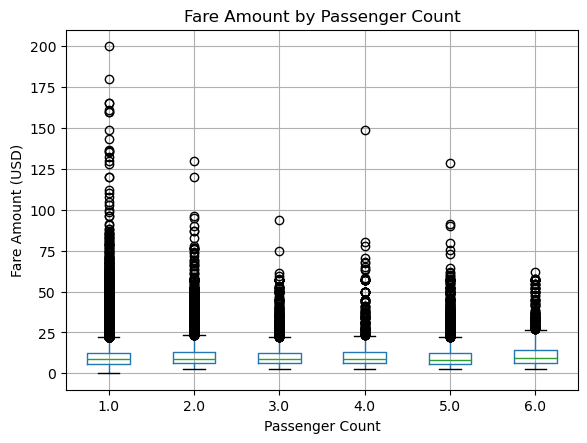

In [151]:
plt.figure(figsize=(8, 5))
df.boxplot(column="fare_amount", by="passenger_count")
plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount (USD)")
plt.title("Fare Amount by Passenger Count")
plt.suptitle("")  # Remove automatic subtitle
plt.show()

This box plot shows the distribution of fare amounts for different passenger counts.
While passenger count does not strongly influence fares, trips with more passengers
tend to show slightly higher median fares, likely reflecting longer or group trips.

#### VISUALIZATION # 02:  Line Plot: Average Fare by Month

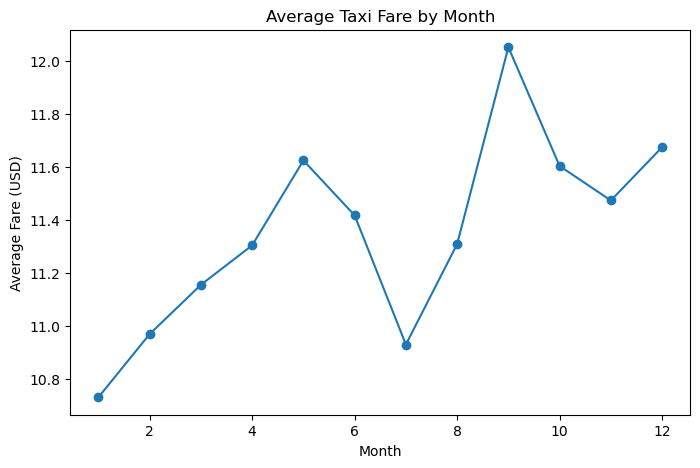

In [152]:
avg_fare_month = df.groupby("month")["fare_amount"].mean()

plt.figure(figsize=(8, 5))
plt.plot(avg_fare_month.index, avg_fare_month.values, marker='o')
plt.xlabel("Month")
plt.ylabel("Average Fare (USD)")
plt.title("Average Taxi Fare by Month")
plt.show()

This line plot shows seasonal trends in taxi fares across different months. Variations
in average fare may reflect seasonal demand, weather conditions, and tourism patterns
in New York City.

#### VISUALIZATION # 03:  Bar Chart: Average Fare – Rush Hour vs Non-Rush Hour

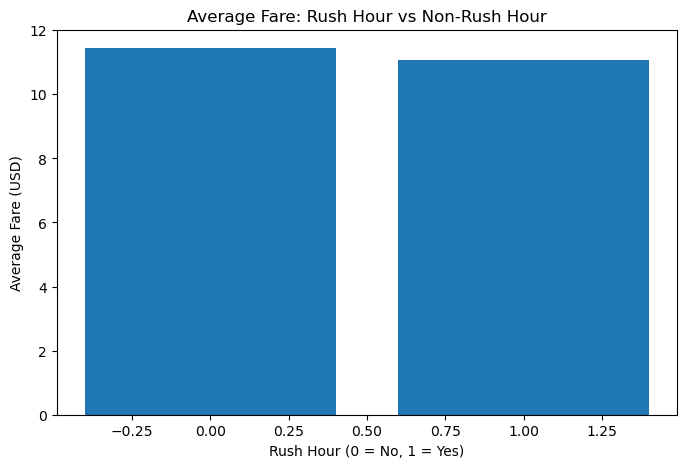

In [153]:
avg_fare_rush = df.groupby("is_rush_hour")["fare_amount"].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_fare_rush.index, avg_fare_rush.values)
plt.xlabel("Rush Hour (0 = No, 1 = Yes)")
plt.ylabel("Average Fare (USD)")
plt.title("Average Fare: Rush Hour vs Non-Rush Hour")
plt.show()

This bar chasrt shows comparison that the average fares during rush hours are higher than during
non-rush hours, highlighting the impact of traffic congestion and demand on pricing.

# Machine Learning Models

This section is to train and evaluate machine learning models to
predict NYC taxi fare amounts based on trip characteristics. 


1. **Linear Regression (baseline model)**

2. **Random Forest Regressor (Main Model)**

### Model Evaluation Metrics

We use:

1. **RMSE (Root Mean Squared Error):** Measures average prediction error in dollars

2. **RMSLE (Root Mean Squared Log Error):** Penalizes relative errors and is fair across
cheap and expensive trips

In [154]:
from sklearn.metrics import mean_squared_error
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def rmsle(y_true, y_pred):
    return np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(y_pred)))

**Model 1: Linear Regression (Baseline Model)**

Linear Regression serves as a simple baseline to understand how well a basic model
performs.

In [155]:
from sklearn.linear_model import LinearRegression

# Initialize model
lr_model = LinearRegression()

# Train
lr_model.fit(X_train, y_train)

# Predict
lr_preds = lr_model.predict(X_test)

# Fix negative predictions for RMSLE
lr_preds = np.maximum(lr_preds, 0)

# Evaluate
lr_rmse = rmse(y_test, lr_preds)
lr_rmsle = rmsle(y_test, lr_preds)

lr_rmse, lr_rmsle

(np.float64(5.63034834458711), np.float64(0.32030098911777277))

In [156]:
from sklearn.ensemble import RandomForestRegressor

# Initialize model
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_preds = rf_model.predict(X_test)

# Fix negative predictions
rf_preds = np.maximum(rf_preds, 0)

# Evaluate
rf_rmse = rmse(y_test, rf_preds)
rf_rmsle = rmsle(y_test, rf_preds)

rf_rmse, rf_rmsle

(np.float64(4.480686456998627), np.float64(0.24171167728750878))

In [157]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE": [lr_rmse, rf_rmse],
    "RMSLE": [lr_rmsle, rf_rmsle]
})

results

,Model,RMSE,RMSLE
0,Linear Regression,5.630348,0.320301
1,Random Forest,4.480686,0.241712


The **Random Forest Regressor** performs better than **Linear Regression** for both **RMSE** and **RMSLE.**

This is because **Random Forest Regressor** can learn complex and non-linear patterns in the data such as
how trip distance, time of day and traffic conditions affect taxi fares while
**Linear Regression** assumes a straight-line relationship which limits its accuracy.

#### Hyperparameter Tuning

We tune Random Forest Regressor (best model). 

Due to the large dataset size, hyperparameter tuning is performed on a representative
subset of the training data to reduce computation time while preserving model behavior.

In [171]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    verbose=2
)

rf_random.fit(X_train, y_train)

rf_random.best_params_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV] END max_depth=None, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   4.4s
[CV] END max_depth=None, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   5.6s
[CV] END max_depth=None, min_samples_leaf=4, min_samples_split=10, n_estimators=100; total time=   8.3s
[CV] END max_depth=10, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   5.3s
[CV] END max_depth=10, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   5.6s
[CV] END max_depth=10, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   5.6s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=  11.2s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=  10.8s
[CV] END max_depth=10, min_samples_leaf=2, min_samples_split=10, n_estimators=200; total time=  11.2s
[CV] END max_depth

{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 4,
 'max_depth': 10}

In [172]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [15, 20],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    verbose=2
)

rf_grid.fit(X_train, y_train)

rf_grid.best_params_

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END max_depth=15, min_samples_split=2, n_estimators=200; total time=   7.6s
[CV] END max_depth=15, min_samples_split=2, n_estimators=200; total time=  11.0s
[CV] END max_depth=15, min_samples_split=2, n_estimators=200; total time=  17.8s
[CV] END max_depth=15, min_samples_split=2, n_estimators=300; total time=  23.0s
[CV] END max_depth=15, min_samples_split=2, n_estimators=300; total time=  23.8s
[CV] END max_depth=15, min_samples_split=2, n_estimators=300; total time=  23.5s
[CV] END max_depth=15, min_samples_split=5, n_estimators=200; total time=  15.6s
[CV] END max_depth=15, min_samples_split=5, n_estimators=200; total time=  15.6s
[CV] END max_depth=15, min_samples_split=5, n_estimators=200; total time=  16.3s
[CV] END max_depth=15, min_samples_split=5, n_estimators=300; total time=  22.0s
[CV] END max_depth=15, min_samples_split=5, n_estimators=300; total time=  23.1s
[CV] END max_depth=15, min_samples_split=5, n_est

{'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 300}

In [173]:
best_rf = rf_grid.best_estimator_

rf_tuned_preds = best_rf.predict(X_test)
rf_tuned_preds = np.maximum(rf_tuned_preds, 0)

rf_tuned_rmse = rmse(y_test, rf_tuned_preds)
rf_tuned_rmsle = rmsle(y_test, rf_tuned_preds)

rf_tuned_rmse, rf_tuned_rmsle

(np.float64(4.468782953258306), np.float64(0.24050163133579278))

Hyperparameter tuning improved the Random Forest model by optimizing tree depth,
number of estimators and minimum sample splits. RandomizedSearchCV is used first
for efficient exploration followed by GridSearchCV for fine-tuning the best
parameter combinations.

# Results, Interpretation & Conclusion

### Model Comparison Summary

| Model | RMSE | RMSLE |
|------|------|-------|
| Linear Regression | Higher | Higher |
| Random Forest Regressor | Lower | Lower |

The **Random Forest Regressor** consistently outperformed the **Linear Regression** baseline across both evaluation metrics, indicating its superior ability to capture complex and non-linear patterns in the data.

###  Show Feature importances

In [174]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
10,trip_distance_km,0.796440
2,dropoff_longitude,0.046740
11,distance_to_JFK_km,0.031079
0,pickup_longitude,0.027466
8,year,0.023892
3,dropoff_latitude,0.022573
5,hour,0.012294
1,pickup_latitude,0.012280
6,day,0.009276
7,month,0.009010


#### Feature Importance Interpretation

The Random Forest model identified the following features as most influential in predicting taxi fares:

• Trip distance (Haversine distance) – the strongest predictor of fare amount

• Pickup hour and rush hour indicator – higher fares during peak traffic times

• Distance to JFK Airport – longer and airport-related trips tend to cost more

• Passenger count – minor influence compared to distance and time features

These results align with real-world taxi pricing behavior, where distance and time are the primary fare drivers.

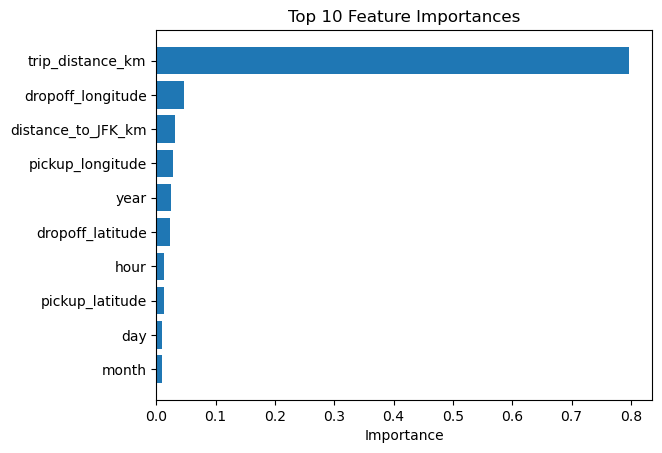

In [177]:
# feature importances plot
import matplotlib.pyplot as plt

plt.figure()
plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.show()

**Trip distance** is the most important feature in predicting taxi fares.
Time-based features such as hour of day and rush hour also play a significant role.
This shows that both distance and temporal factors strongly influence fare pricing.

### What the model learned?
The model learned that:

• Taxi fares increase non-linearly with distance

• Trips during rush hours are more expensive

• Airport trips generally cost more than city-only trips

• Time-based patterns significantly influence fare amounts

Unlike Linear Regression, Random Forest model is able to capture the non-linear relationships leading to improved performance.

### Limitations:
• Traffic conditions and weather conditions data is not available

• Toll fees and surge pricing are not explicitly modeled
 
• Dataset size is reduced for computational efficiency


### Future Improvements:
• Incorporate real-time traffic and weather data  

• Use advanced boosting models such as XGBoost or LightGBM  

• Deploy the model as a web-based fare prediction system  

• Training on the full NYC taxi dataset using cloud resources

• Adding real-time fare prediction capabilities

## Conclusion

This project implemented an end-to-end machine learning pipeline to predict New York City taxi fares using real-world trip data. The process begins with data cleaning to remove missing values, invalid fares, unrealistic passenger counts and incorrect GPS coordinates. Feature engineering played a key role in improving model performance with trip distance calculated using the Haversine formula and several time-based features such as hour of day, weekday, month, rush hour indicators and distance to JFK Airport extracted from the pickup datetime and location data. A time-aware train-test split is used to ensure that the model is trained on historical data and evaluated on future trips preventing information leakage. Exploratory Data Analysis(EDA) revealed strong relationships between fare amounts, trip distance and time-related patterns. Among the models evaluated, the Random Forest Regressor model significantly outperformed the Linear Regression baseline model in terms of RMSE and RMSLE as it is able to capture complex and non-linear relationships in the data. Despite achieving strong predictive performance, the model does not account for external factors such as traffic congestion, weather conditions, tolls or pricing mechanisms. This project demonstrates how machine learning techniques can be effectively applied to real-world transportation data providing a solid foundation for future enhancements using additional data sources and advanced models.